<a href="https://colab.research.google.com/github/amankrpandey1/face-emotion-detection-using-cnn-and-opencv/blob/main/emotion_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction
<hr>

Les humains communiquent en utilisant des expressions faciales ainsi que d'autres langages corporels et des indices verbaux. Les chercheurs utilisent des approches d'apprentissage profond en intelligence artificielle pour aider à la prise de décisions. Ils doivent étudier les personnes afin de prédire comment elles réagiront ou savoir ce qu'elles ressentent. Cette étude propose le développement d'un système qui prédit et classe les émotions faciales en utilisant l'algorithme de réseau de neurones convolutifs, parmi d'autres caractéristiques. La prétraitement des données, l'extraction des caractéristiques faciales et la classification des émotions faciales sont les trois étapes clés de ce carnet. Les expressions faciales ont été prédites avec une précision de 62,66 % à l'aide du réseau de neurones convolutifs (CNN). Cet algorithme a été évalué sur une base de données provenant de [FER2013](https://www.kaggle.com/datasets/deadskull7/fer2013), qui contient **35887 images en niveaux de gris 48x48** représentant chacune des émotions.

<br>

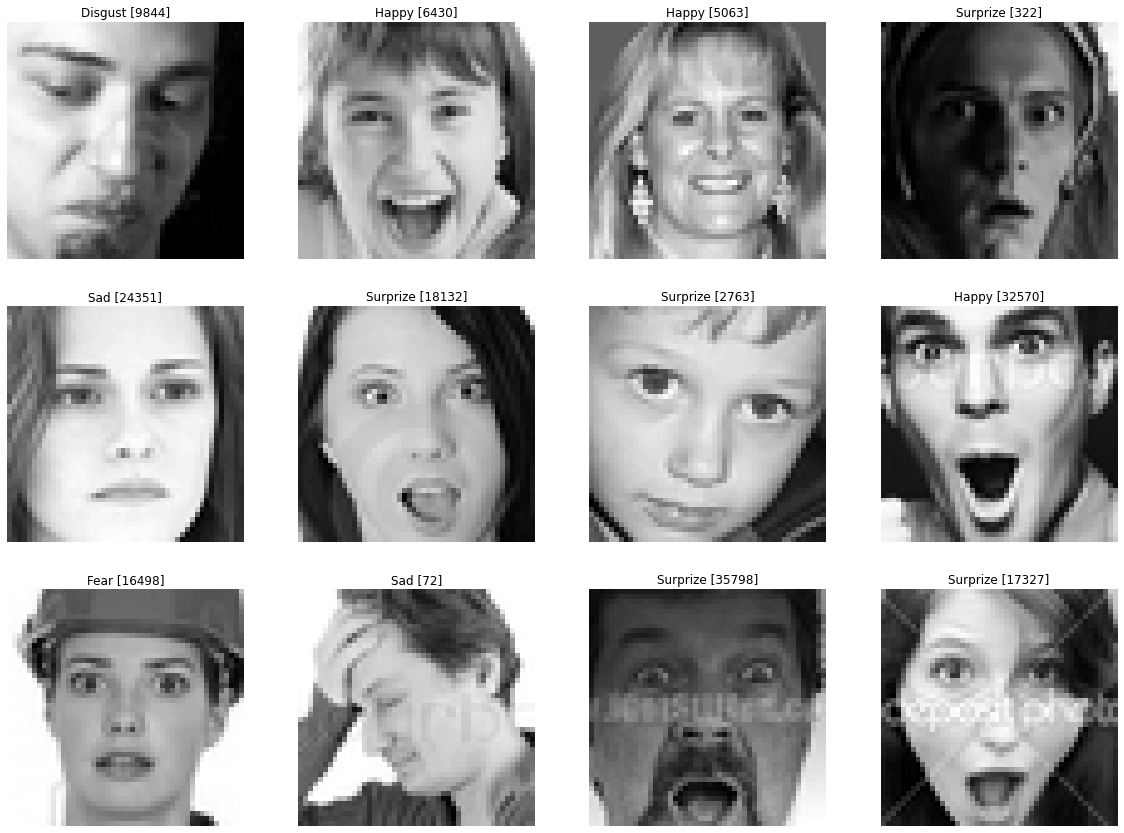

**Pourquoi utiliser un CNN pour la détection des émotions ?**

Les Réseaux de Neurones Convolutifs (CNN) sont particulièrement adaptés à la détection des émotions, surtout à partir d'images ou de vidéos. Voici pourquoi :

1.  Les émotions sont des patterns visuels locaux
Les expressions faciales reposent sur des caractéristiques locales et hiérarchiques : Le CNN est conçu pour détecter exactement ce type de patterns locaux grâce à ses filtres convolutifs.

2. Extraction automatique des features
Contrairement aux méthodes classiques (HOG, LBP...) qui nécessitent une extraction manuelle de features, le CNN apprend automatiquement les caractéristiques les plus discriminantes du visage, sans intervention humaine.

3.  Invariance spatialeGrâce au pooling, le CNN est robuste aux petites variations de :Position du visage, Taille, Légères rotations





**En résumé**

Le CNN est le choix naturel car les émotions = patterns visuels locaux et hiérarchiques, ce qui correspond exactement à ce que les CNN savent faire le mieux.

Tu travailles sur un projet de détection d'émotions ? Je peux t'aider à construire une architecture CNN adaptée.

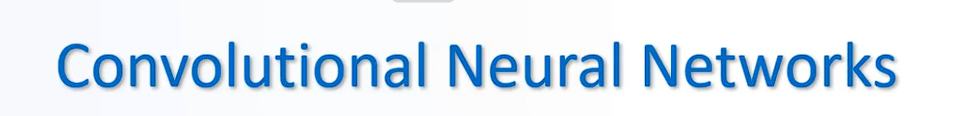

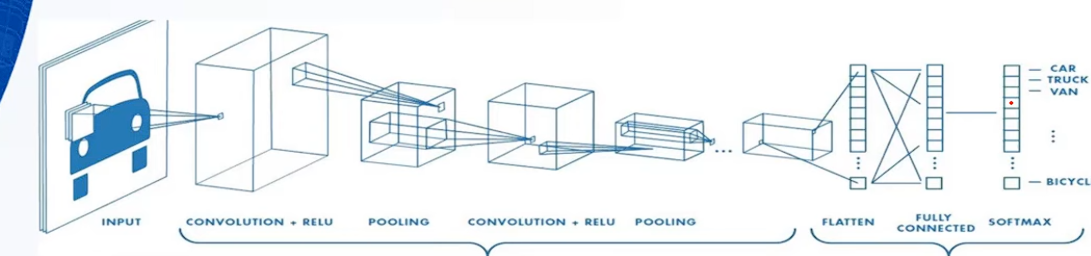

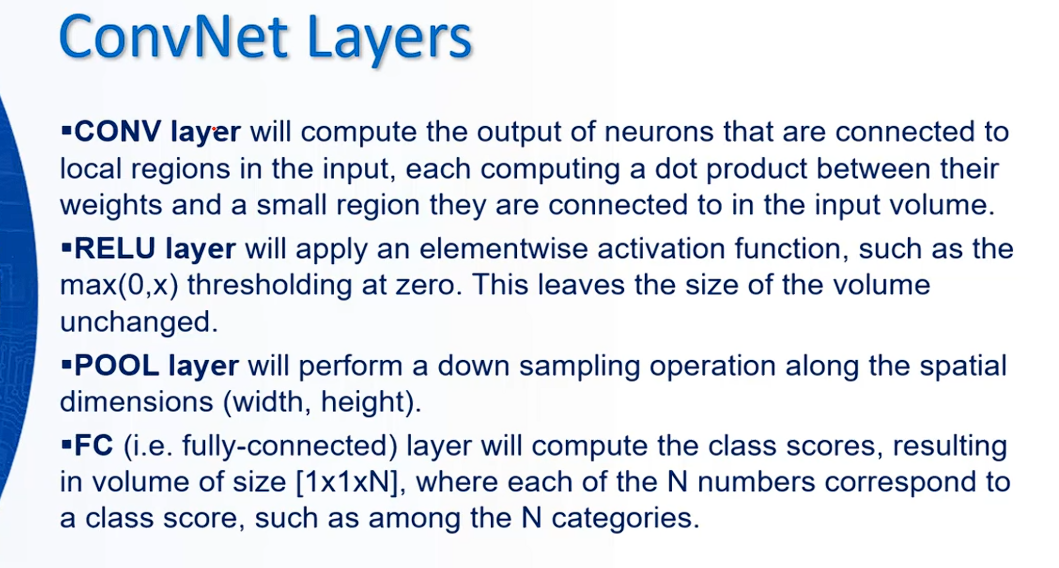

#Setting up kaggle api for getting the datset
<hr>

####For that you can go to kaggle.com-> your profile-> Account-> Create New API Token
Then upload the kaggle.json file in google collab and then run the below commands

In [5]:
! pip install kaggle
! mkdir ~/.kaggle #creating a hidden directory
! cp kaggle.json ~/.kaggle/ #pasting the kaggle api token to above dir
! chmod 600 ~/.kaggle/kaggle.json ## chaging the mode for the file

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


**Put the name of the dataset that you want to use and then unzip the dataset**

In [6]:
! kaggle datasets download deadskull7/fer2013 # downloading the datset

Dataset URL: https://www.kaggle.com/datasets/deadskull7/fer2013
License(s): CC0-1.0
100% 96.6M/96.6M [00:02<00:00, 35.1MB/s]



In [7]:
! unzip /content/fer2013.zip #unzip the downloaded dataset

Archive:  /content/fer2013.zip
  inflating: fer2013.csv             


#Importing necesaary files
<hr>



In [8]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, Conv2D,MaxPool2D,ZeroPadding2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import vgg16
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

#for model deployement
import os
import cv2
import numpy as np
from tensorflow.keras.models import model_from_json
from tensorflow.keras.utils import img_to_array

In [9]:
df = pd.read_csv('./fer2013.csv') #read dataset

df.tail(-5),df.shape  #first five rows and count of rows and columns

(       emotion                                             pixels        Usage
 5            2  55 55 55 55 55 54 60 68 54 85 151 163 170 179 ...     Training
 6            4  20 17 19 21 25 38 42 42 46 54 56 62 63 66 82 1...     Training
 7            3  77 78 79 79 78 75 60 55 47 48 58 73 77 79 57 5...     Training
 8            3  85 84 90 121 101 102 133 153 153 169 177 189 1...     Training
 9            2  255 254 255 254 254 179 122 107 95 124 149 150...     Training
 ...        ...                                                ...          ...
 35882        6  50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...  PrivateTest
 35883        3  178 174 172 173 181 188 191 194 196 199 200 20...  PrivateTest
 35884        0  17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...  PrivateTest
 35885        3  30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...  PrivateTest
 35886        2  19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...  PrivateTest
 
 [35882 rows x 3 columns],
 (35887, 3)

#Exploraotry Data Analysis
<hr>



In [10]:
print("Null values present in the file:",df.isna().sum().sum())
print("Basic information about the dataframe:")
df.info()

df.describe()

Null values present in the file: 0
Basic information about the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   pixels   35887 non-null  object
 2   Usage    35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB


,emotion
count,35887.000000
mean,3.323265
std,1.873819
min,0.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,6.000000


In [11]:
emotions = { #list of available emotions in the dataset
    0:"Angry",
    1:"Disgust",
    2:"Fear",
    3:"Happy",
    4:"Sad",
    5:"Surprize",
    6:"Neutral"
}

##No of images present in dataset corresponding to each emotion

In [12]:
count_emotions = (df.groupby(df['emotion'])['pixels'].count()).to_frame()
count_emotions['emotion name'] = [emotions[k] for k in emotions.keys()]
count_emotions

,pixels,emotion name
emotion,,
0,4953,Angry
1,547,Disgust
2,5121,Fear
3,8989,Happy
4,6077,Sad
5,4002,Surprize
6,6198,Neutral


##No of images present in dataset corresponding to training testing and validation part

In [13]:
count_usage = (df.groupby(df['Usage'])['pixels'].count()).to_frame()
count_usage

,pixels
Usage,
PrivateTest,3589
PublicTest,3589
Training,28709


##Visualizing images from the dataset

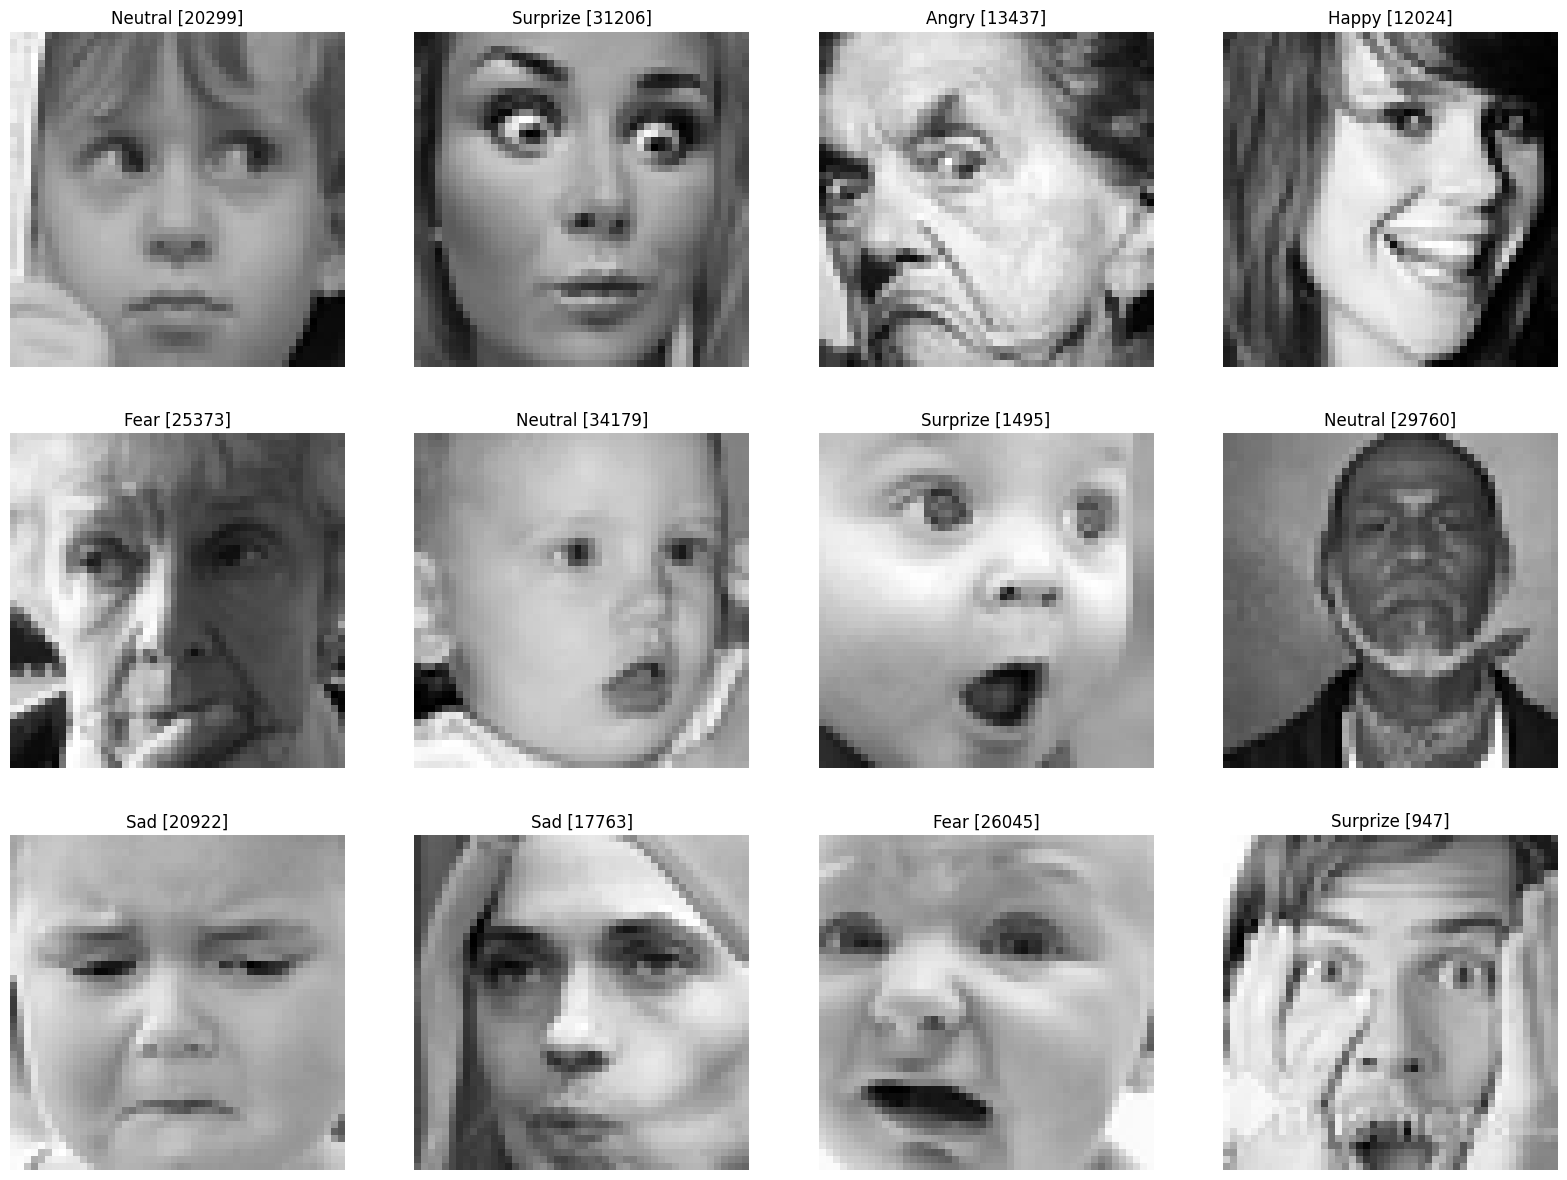

In [14]:
# from PIL import Image
# pixels = df['pixels'][0]
# b = bytes(int(p) for p in pixels.split())
# i = Image.frombuffer('L',(48,48),b)
# di.save('a.png')
def visualize_images(n_img=4):
    indices = np.random.randint(0,df.shape[0],size=n_img)
#     print(indices)
    plt.figure(figsize=(20,20))
    for i,l in zip(indices,range(0,len(indices))):
        image_ar = np.array([i for i in  df['pixels'][i].split()] , dtype='float')
        pixels = np.reshape(image_ar,(48,48))
        ax = plt.subplot(4,4,l+1)
        plt.imshow(pixels,cmap='gray')
        plt.title(emotions[df['emotion'][i]]+" ["+str(i)+"]")
        plt.xticks()
        plt.yticks([])
        plt.axis("off")
visualize_images(12)

#Data Preprocessing
<hr>

## Extracting rows for each part

In [15]:
X_train,y_train = [],[]
X_val,y_val = [],[]
X_test,y_test = [],[]
for index,row in df.iterrows():
    k = row['pixels'].split(" ")
    if row['Usage'] == 'Training':
        X_train.append(np.array(k))
        y_train.append(row['emotion'])
    elif row['Usage'] == 'PrivateTest':
        X_test.append(np.array(k))
        y_test.append(row['emotion'])
    elif row['Usage'] == 'PublicTest':
        X_val.append(np.array(k))
        y_val.append(row['emotion'])

X_train = np.array(X_train,dtype='float')
y_train = np.array(y_train)
X_test = np.array(X_test,dtype='float')
y_test = np.array(y_test)
X_val = np.array(X_val,dtype='float')
y_val = np.array(y_val)

In [16]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_val.shape,y_val.shape

((28709, 2304), (28709,), (3589, 2304), (3589,), (3589, 2304), (3589,))

**we have to change the shape of the images to train them as the above shape is not compatible**

In [17]:
# From (28709, 2304) → (28709, 48, 48, 1)
# Because Conv2D expects images in the format (samples, height, width, channels), not flat vectors. So we restore the original 2D shape of the image + 1 for grayscale channel.

X_train = X_train.reshape(X_train.shape[0],48,48,1)
X_test = X_test.reshape(X_test.shape[0],48,48,1)
X_val = X_val.reshape(X_val.shape[0],48,48,1)

y_train = to_categorical(y_train,num_classes=7)
y_test = to_categorical(y_test,num_classes=7)
y_val = to_categorical(y_val,num_classes=7)

X_train.shape,y_train.shape,X_test.shape,y_test.shape,X_val.shape,y_val.shape


((28709, 48, 48, 1),
 (28709, 7),
 (3589, 48, 48, 1),
 (3589, 7),
 (3589, 48, 48, 1),
 (3589, 7))

#Defining Model Archietechture

VGG16

In [18]:
def cnn_model():
  model = Sequential()

  model.add(ZeroPadding2D((1,1),input_shape=(48,48,1),name="block1_pad1"))
  model.add(Conv2D(64, (3, 3), activation='relu',name="block1_l1"))
  model.add(ZeroPadding2D((1,1),name="block1_pad2"))
  model.add(Conv2D(64, (3, 3), activation='relu',name="block1_l2"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool1"))

  model.add(ZeroPadding2D((1,1),name="block2_pad1"))
  model.add(Conv2D(128, (3, 3), activation='relu',name="block2_l1"))
  model.add(ZeroPadding2D((1,1),name="block2_l2"))
  model.add(Conv2D(128, (3, 3), activation='relu',name="block2_pad2"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool2"))

  model.add(ZeroPadding2D((1,1),name="block3_pad1"))
  model.add(Conv2D(256, (3, 3), activation='relu',name="block3_l1"))
  model.add(ZeroPadding2D((1,1),name="block3_pad2"))
  model.add(Conv2D(256, (3, 3), activation='relu',name="block3_l2"))
  model.add(ZeroPadding2D((1,1),name="block3_pad3"))
  model.add(Conv2D(256, (3, 3), activation='relu',name="block3_l3"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool3"))


  model.add(ZeroPadding2D((1,1),name="block4_pad1"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block4_l1"))
  model.add(ZeroPadding2D((1,1),name="block4_pad2"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block4_l2"))
  model.add(ZeroPadding2D((1,1),name="block4_pad3"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block4_l3"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool4"))


  model.add(ZeroPadding2D((1,1),name="block5_pad1"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block5_l1"))
  model.add(ZeroPadding2D((1,1),name="block5_pad2"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block5_l2"))
  model.add(ZeroPadding2D((1,1), name="block5_pad3"))
  model.add(Conv2D(512, (3, 3), activation='relu',name="block5_l3"))
  model.add(MaxPool2D((2,2), strides=(2,2),name="pool5"))

  model.add(Flatten()) # # aplatit en 1D
  model.add(Dense(4096, activation='relu',name="block6")) # couche fully connected
  model.add(Dropout(0.5,name="drop1")) # désactive 50% des neurones → évite l'overfitting
  model.add(Dense(4096, activation='relu',name="block7")) # idem
  model.add(Dropout(0.5,name="drop2"))
  model.add(Dense(7, activation='softmax',name="block8")) # sortie → 7 probabilités (une par émotion)

  return model



*   ZeroPadding2D → ajoute des zéros autour de l'image pour garder la taille


*   Conv2D → détecte des patterns (bords, formes...) avec des filtres


*   MaxPool2D → réduit la taille de l'image de moitié

*   Flatten → transforme la matrice en vecteur 1D



*   Dense → couche fully connected, fait la classification


*   Dropout → désactive aléatoirement des neurones pour éviter l'overfitting

*   relu → activation : met les valeurs négatives à 0

*   softmax → convertit la sortie en 7 probabilités (une par émotion)






In [19]:
model = cnn_model()
model.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_pad1 (ZeroPadding2D)     │ (None, 50, 50, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_l1 (Conv2D)              │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pad2 (ZeroPadding2D)     │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_l2 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pad1 (ZeroPadding2D)     │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_l1 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_l2 (ZeroPadding2D)       │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pad2 (Conv2D)            │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pad1 (ZeroPadding2D)     │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_l1 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pad2 (ZeroPadding2D)     │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_l2 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pad3 (ZeroPadding2D)     │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_l3 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pad1 (ZeroPadding2D)     │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_l1 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pad2 (ZeroPadding2D)     │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_l2 (Conv2D)              │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pad3 (ZeroPadding2D)     │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_l3 (Conv2D)              │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pad1 (ZeroPadding2D)     │ (None, 5, 5, 512)      │             

 Total params: 33,624,775 (128.27 MB)

 Trainable params: 33,624,775 (128.27 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
checkpointer = [EarlyStopping(monitor = 'val_accuracy', verbose = 1,
                              restore_best_weights=True,mode="max",patience = 10),
                              ModelCheckpoint('best_model.h5',monitor="val_accuracy",verbose=1,
                              save_best_only=True,mode="max")]

history = model.fit(
    X_train,
    y_train,
    batch_size=32, # traite 32 images à la fois
    epochs=30, # répète 30 fois sur tout le dataset
    callbacks=checkpointer, # active les 2 gardiens
    validation_data=(X_val,y_val) # # évalue sur val à chaque epoch
)

#  EarlyStopping → arrête l'entraînement si val_accuracy ne s'améliore pas pendant 10 epochs (patience=10), et restaure les meilleurs poids
# ModelCheckpoint → sauvegarde le modèle dans best_model.h5 à chaque fois que val_accuracy s'améliore

Epoch 1/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2438 - loss: 1.8375
Epoch 1: val_accuracy improved from None to 0.24937, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 60s 55ms/step - accuracy: 0.2480 - loss: 1.8241 - val_accuracy: 0.2494 - val_loss: 1.8040
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2644 - loss: 1.7848
Epoch 2: val_accuracy did not improve from 0.24937
898/898 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.2895 - loss: 1.7497 - val_accuracy: 0.1491 - val_loss: 1.9176
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3665 - loss: 1.6195
Epoch 3: val_accuracy improved from 0.24937 to 0.33631, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.3812 - loss: 1.5824 - val_accuracy: 0.3363 - val_loss: 1.6951
Epoch 4/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4130 - loss: 1.5036
Epoch 4: val_accuracy improved from 0.33631 to 0.41070, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.4286 - loss: 1.4710 - val_accuracy: 0.4107 - val_loss: 1.6197
Epoch 5/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4608 - loss: 1.4033
Epoch 5: val_accuracy improved from 0.41070 to 0.46085, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.4694 - loss: 1.3810 - val_accuracy: 0.4609 - val_loss: 1.4055
Epoch 6/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5029 - loss: 1.3013
Epoch 6: val_accuracy did not improve from 0.46085
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.5078 - loss: 1.2874 - val_accuracy: 0.3750 - val_loss: 1.6010
Epoch 7/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5445 - loss: 1.2088
Epoch 7: val_accuracy improved from 0.46085 to 0.49763, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.5462 - loss: 1.1990 - val_accuracy: 0.4976 - val_loss: 1.3162
Epoch 8/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5802 - loss: 1.1187
Epoch 8: val_accuracy improved from 0.49763 to 0.54667, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.5800 - loss: 1.1176 - val_accuracy: 0.5467 - val_loss: 1.1973
Epoch 9/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6130 - loss: 1.0327
Epoch 9: val_accuracy did not improve from 0.54667
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.6069 - loss: 1.0410 - val_accuracy: 0.4372 - val_loss: 1.7757
Epoch 10/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6465 - loss: 0.9510
Epoch 10: val_accuracy did not improve from 0.54667
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.6443 - loss: 0.9552 - val_accuracy: 0.5450 - val_loss: 1.2395
Epoch 11/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6911 - loss: 0.8414
Epoch 11: val_accuracy did not improve from 0.54667
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.6809 - loss: 0.8632 - val_accuracy: 0.5135 - val_loss: 1.5234
Epoch 12/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - a


Epoch 14: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.7798 - loss: 0.6043 - val_accuracy: 0.5812 - val_loss: 1.3971
Epoch 15/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8276 - loss: 0.4811
Epoch 15: val_accuracy did not improve from 0.58122
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.8155 - loss: 0.5133 - val_accuracy: 0.5166 - val_loss: 1.8718
Epoch 16/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8544 - loss: 0.4183
Epoch 16: val_accuracy did not improve from 0.58122
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.8409 - loss: 0.4519 - val_accuracy: 0.5481 - val_loss: 1.7382
Epoch 17/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8724 - loss: 0.3545
Epoch 17: val_accuracy did not improve from 0.58122
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.8655 - loss: 0.3814 - val_accuracy: 0.5481 - val_loss: 1.7584
Epoch 18/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step 


Epoch 23: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.9525 - loss: 0.1440 - val_accuracy: 0.5876 - val_loss: 2.3052
Epoch 24/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9655 - loss: 0.1091
Epoch 24: val_accuracy did not improve from 0.58763
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.9588 - loss: 0.1265 - val_accuracy: 0.5765 - val_loss: 2.4165
Epoch 25/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9645 - loss: 0.1115
Epoch 25: val_accuracy did not improve from 0.58763
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.9612 - loss: 0.1214 - val_accuracy: 0.5573 - val_loss: 2.0278
Epoch 26/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9693 - loss: 0.0979
Epoch 26: val_accuracy did not improve from 0.58763
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.9664 - loss: 0.1072 - val_accuracy: 0.5871 - val_loss: 2.2854
Epoch 27/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step 


Epoch 27: finished saving model to best_model.h5
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.9736 - loss: 0.0823 - val_accuracy: 0.5896 - val_loss: 2.4096
Epoch 28/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9788 - loss: 0.0700
Epoch 28: val_accuracy did not improve from 0.58958
898/898 ━━━━━━━━━━━━━━━━━━━━ 45s 50ms/step - accuracy: 0.9735 - loss: 0.0835 - val_accuracy: 0.5216 - val_loss: 2.8567
Epoch 29/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9729 - loss: 0.0841
Epoch 29: val_accuracy did not improve from 0.58958
898/898 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.9731 - loss: 0.0815 - val_accuracy: 0.5734 - val_loss: 2.2997
Epoch 30/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9786 - loss: 0.0669
Epoch 30: val_accuracy did not improve from 0.58958
898/898 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.9745 - loss: 0.0783 - val_accuracy: 0.5617 - val_loss: 2.7215
Restoring model weights from the end of the best epoch

#Model Evaluation
<hr>

Lets see the output resutls <br>
* Loss plot
* Images with their predicted vs actual label
* Confusion Matrix
* Classification Reprot

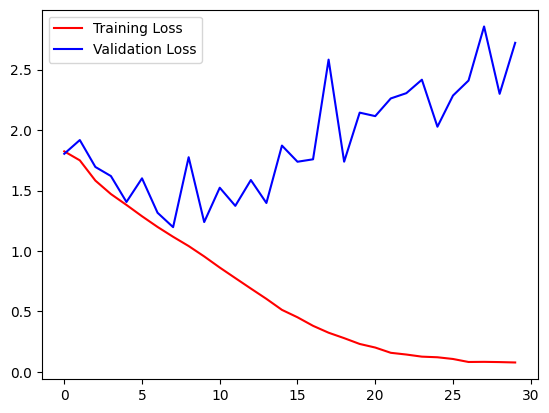

In [21]:
def loss_plot(history):
  plt.plot(history.history["loss"],'r', label="Training Loss")
  plt.plot(history.history["val_loss"],'b', label="Validation Loss")
  plt.legend()

loss_plot(history)

In [22]:
# Model Inference
preds = model.predict(X_test)
y_pred = np.argmax(preds , axis = 1 )

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


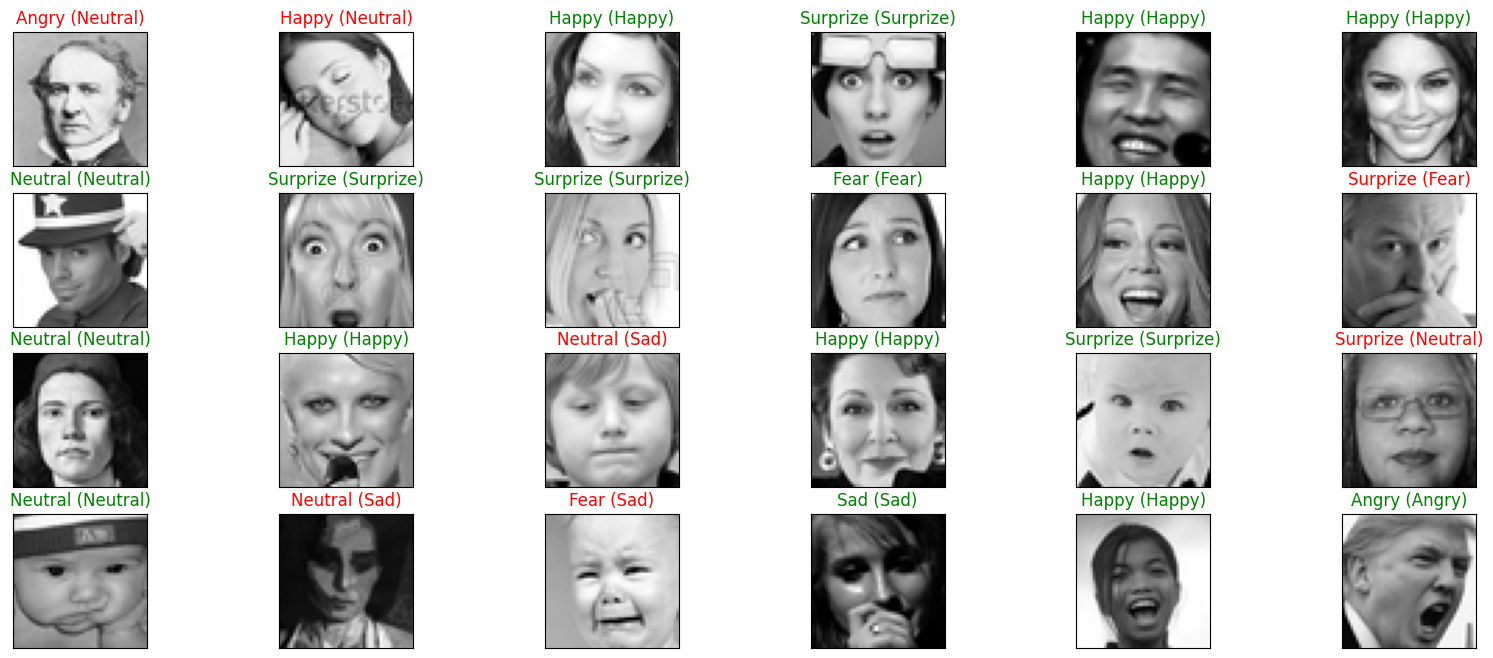

In [23]:
#function to plot images with their lables(actual vs predicted)
def check_images(X_test,y_pred,label_dict={}):

  figure = plt.figure(figsize=(20, 8))
  for i, index in enumerate(np.random.choice(X_test.shape[0], size=24, replace=False)):
      ax = figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
      ax.imshow(np.squeeze(X_test[index]),cmap="gray")
      predict_index = label_dict[(y_pred[index])]
      true_index = label_dict[np.argmax(y_test,axis=1)[index]]

      ax.set_title("{} ({})".format((predict_index),
                                    (true_index)),
                                    color=("green" if predict_index == true_index else "red"))
check_images(X_test,y_pred,emotions)

**On peut constater que les émotions comme la peur, la colère ou la neutralité sont souvent moins bien détectées (plus "faibles"). Cependant, ce n'est pas un problème majeur pour notre programme, car nos émotions essentielles sont la joie (sourire) et la tristesse. Nous avons intégré les autres catégories uniquement pour isoler les données et maximiser la précision sur les deux émotions qui nous intéressent vraiment.**

In [24]:
# function to plot confusion matrix
def conf_mat(y_test,y_pred,labels=['Anger', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sadness', "Surprise"]):
  CLASS_LABELS  = labels
  cm_data = confusion_matrix(np.argmax(y_test, axis = 1 ), y_pred)
  cm = pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
  cm.index.name = 'Actual'
  cm.columns.name = 'Predicted'
  plt.figure(figsize = (20,10))
  plt.title('Confusion Matrix', fontsize = 20)
  sns.set(font_scale=1.2)
  ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

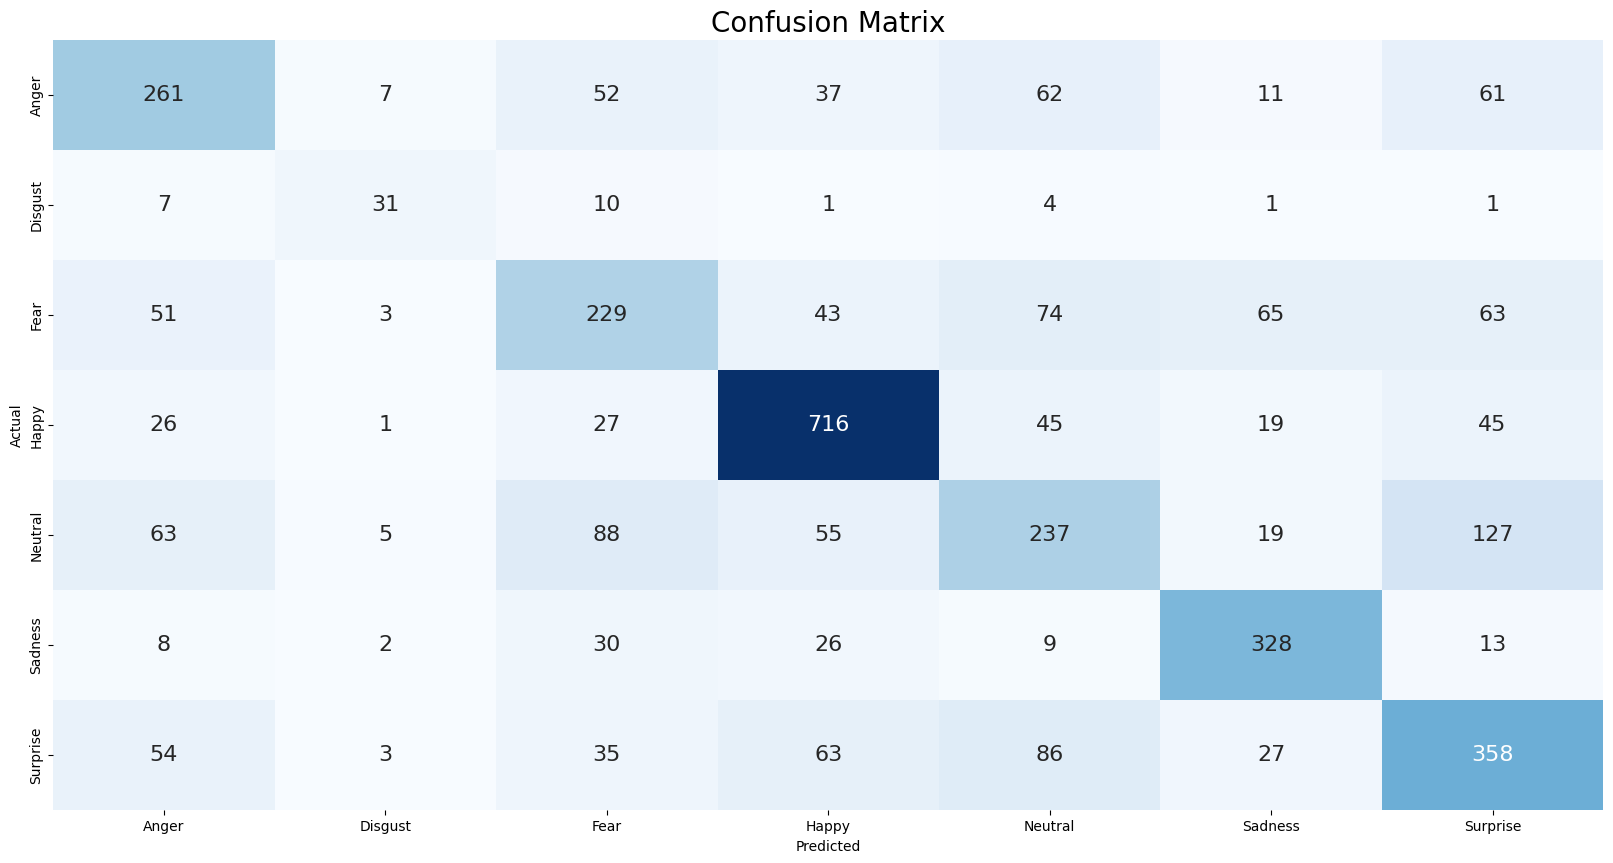

In [25]:
conf_mat(y_test,y_pred)

In [26]:
#classification report
print(classification_report(np.argmax(y_test, axis = 1 ),y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.555     0.532     0.543       491
           1      0.596     0.564     0.579        55
           2      0.486     0.434     0.458       528
           3      0.761     0.815     0.787       879
           4      0.458     0.399     0.427       594
           5      0.698     0.788     0.740       416
           6      0.536     0.572     0.553       626

    accuracy                          0.602      3589
   macro avg      0.584     0.586     0.584      3589
weighted avg      0.593     0.602     0.596      3589



In [27]:
 # loss and accuracy
loss_and_metrics = model.evaluate(X_train,y_train)
print("On Training Data",loss_and_metrics)

loss_and_metrics = model.evaluate(X_val,y_val)
print("On Validation Data",loss_and_metrics)

loss_and_metrics = model.evaluate(X_test,y_test)
print("On Test Data",loss_and_metrics)


898/898 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9821 - loss: 0.0613
On Training Data [0.06127557530999184, 0.9820961952209473]
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5896 - loss: 2.4096
On Validation Data [2.4096169471740723, 0.5895792841911316]
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6018 - loss: 2.3659
On Test Data [2.3658807277679443, 0.6018389463424683]


#Fine Tuning
<hr>

Let's try to improve the model

##1. Changing epoch, learning rate and batch size

In [28]:
model = cnn_model()
model.compile(optimizer=SGD(learning_rate=0.005),loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=60,
    callbacks=checkpointer,
    validation_data=(X_val,y_val)
)


# optimizer=SGD(learning_rate=0.005) : C'est le moteur qui ajuste les poids du modèle.

# SGD (Stochastic Gradient Descent) est l'algorithme qui cherche le chemin vers l'erreur minimale.
# Learning rate (0.005) : C'est la taille des "pas" que fait le modèle. S'ils sont trop grands, il rate la solution ; s'ils sont trop petits, c'est trop lent.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.2276 - loss: 1.8572
Epoch 1: val_accuracy did not improve from 0.58958
449/449 ━━━━━━━━━━━━━━━━━━━━ 67s 120ms/step - accuracy: 0.2436 - loss: 1.8345 - val_accuracy: 0.2494 - val_loss: 1.8197
Epoch 2/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2470 - loss: 1.8188
Epoch 2: val_accuracy did not improve from 0.58958
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 87ms/step - accuracy: 0.2512 - loss: 1.8161 - val_accuracy: 0.2494 - val_loss: 1.8079
Epoch 3/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2532 - loss: 1.8065
Epoch 3: val_accuracy did not improve from 0.58958
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 88ms/step - accuracy: 0.2550 - loss: 1.7991 - val_accuracy: 0.2750 - val_loss: 1.7657
Epoch 4/60
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2836 - loss: 1.7620
Epoch 4: val_accuracy did not improve from 0.58958
449/449 ━━━━━━━━━━━━━━━━━━━━ 39s 87ms/step - accuracy: 0.2955 - loss: 1.7485 - val_accura

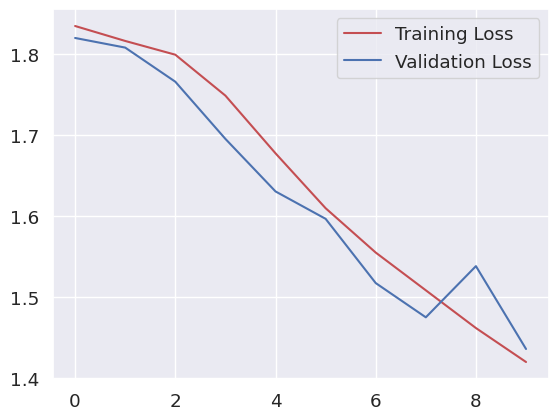

In [29]:
loss_plot(history)

In [30]:
preds = model.predict(X_test)
y_pred = np.argmax(preds , axis = 1 )
print(classification_report(np.argmax(y_test, axis = 1 ),y_pred,digits=3))

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       491
           1      0.000     0.000     0.000        55
           2      0.000     0.000     0.000       528
           3      0.245     1.000     0.393       879
           4      0.000     0.000     0.000       594
           5      0.000     0.000     0.000       416
           6      0.000     0.000     0.000       626

    accuracy                          0.245      3589
   macro avg      0.035     0.143     0.056      3589
weighted avg      0.060     0.245     0.096      3589



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##2. Changing optimizer

In [31]:
# loss and accuracy

model = cnn_model()
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    X_train,
    y_train,
    batch_size=64,
    epochs=50,
    callbacks=checkpointer,
    validation_data=(X_val,y_val)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.2500 - loss: 1.8190
Epoch 1: val_accuracy did not improve from 0.58958
449/449 ━━━━━━━━━━━━━━━━━━━━ 67s 128ms/step - accuracy: 0.2805 - loss: 1.7620 - val_accuracy: 0.3678 - val_loss: 1.5902
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.3979 - loss: 1.5358
Epoch 2: val_accuracy did not improve from 0.58958
449/449 ━━━━━━━━━━━━━━━━━━━━ 50s 111ms/step - accuracy: 0.4212 - loss: 1.4766 - val_accuracy: 0.4742 - val_loss: 1.3704
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4863 - loss: 1.3274
Epoch 3: val_accuracy did not improve from 0.58958
449/449 ━━━━━━━━━━━━━━━━━━━━ 49s 110ms/step - accuracy: 0.4993 - loss: 1.2939 - val_accuracy: 0.5068 - val_loss: 1.2757
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.5493 - loss: 1.1723
Epoch 4: val_accuracy did not improve from 0.58958
449/449 ━━━━━━━━━━━━━━━━━━━━ 50s 111ms/step - accuracy: 0.5537 - loss: 1.1614 - val_

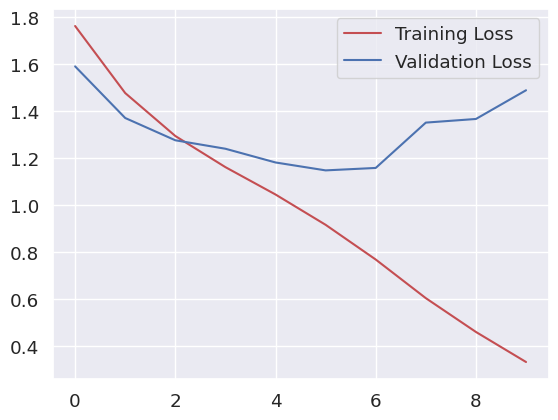

In [32]:
loss_plot(history)

In [33]:
print(classification_report(np.argmax(y_test, axis = 1 ),y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.000     0.000     0.000       491
           1      0.000     0.000     0.000        55
           2      0.000     0.000     0.000       528
           3      0.245     1.000     0.393       879
           4      0.000     0.000     0.000       594
           5      0.000     0.000     0.000       416
           6      0.000     0.000     0.000       626

    accuracy                          0.245      3589
   macro avg      0.035     0.143     0.056      3589
weighted avg      0.060     0.245     0.096      3589



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Observation

Seems like the model is getting overfitted by the data and the same arch. is not giving better results after tuning.
More steps that can be taken to improve the performance
1. Adding regularization in the model Arch.
2. Adding more data in validation set
3. Try with diff cnn arch

#Model Saving

In [34]:
model_json = model.to_json()
with open("model.json", "w") as json_file:
  json_file.write(model_json)
# model.save_weights("model.h5")
print("Saved model to disk")

Saved model to disk


#Deploying model using OpenCV
<hr>

Note: Run the below code in your local machine

##loading model arch and weights

In [35]:
model = model_from_json(open("model.json", "r").read())
model.load_weights('best_model.h5')
face_haar_cascade = cv2.CascadeClassifier('./haarcascade_frontalface_default.xml')

##Open CV code for webcam and prediction

In [36]:
cap=cv2.VideoCapture(0) # start webcam
while True:
    (valid,test_image)=cap.read() #reading image from video frame
    if not valid: #if not getting frames then exit
        break

    gray_image= cv2.cvtColor(test_image, cv2.COLOR_BGR2GRAY) #converting the rgb image to grayscale


    faces_detected = face_haar_cascade.detectMultiScale(gray_image) #detecting faces from the image using haar_cascade
    for (x,y,w,h) in faces_detected: #cordinates of deteced faces
        cv2.rectangle(gray_image,(x,y), (x+w,y+h), (255,0,0)) #putting a rectange box around detected face
        roi_gray=gray_image[y:y+w,x:x+h]  # capturing only face from the image
        roi_gray=cv2.resize(roi_gray,(48,48)) # resizing it to 48,48 (that's what mdodel wants as an input)
        image_pixels = img_to_array(roi_gray) #converting image to array
        image_pixels = np.expand_dims(image_pixels, axis = 0) #expanding dims as model needs input in batches
        # image_pixels /= 255


        predictions = model.predict(image_pixels) #model prediction
        max_index = np.argmax(predictions[0]) #getting emotion index

        emotion_detection = ('angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral')
        emotion_prediction = emotion_detection[max_index]


        cv2.putText(test_image, emotion_prediction, (int(x), int(y)),cv2.FONT_HERSHEY_SIMPLEX,2,(0,255,0),3) #putting text around face
    #   cv2.putText(frame,label,label_position,cv2.FONT_HERSHEY_SIMPLEX,2,(0,255,0),3)


        resize_image = cv2.resize(test_image, (1000, 700)) #enhancing the image to display
        cv2.imshow('Emotion Dectector',resize_image)
        if cv2.waitKey(10) == ord('b'):
            break
cap.release()
cv2.destroyAllWindows

<function destroyAllWindows>

In [42]:
from google.colab import files

# Sauvegarde le modèle dans l'espace temporaire de Colab
model.save('modele_emotion.h5')

# Télécharge-le sur ton ordinateur
files.download('modele_emotion.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
p